In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras import backend as K
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.mixture import GaussianMixture

2025-12-22 08:09:40.354997: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766390980.583118      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766390980.644671      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
df_train = pd.read_csv("/kaggle/input/heartbeat/mitbih_train.csv", header=None)
df_test  = pd.read_csv("/kaggle/input/heartbeat/mitbih_test.csv", header=None)
df = pd.concat([df_train, df_test], axis=0)

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

X_normal = X[y == 0]
X_anomali = X[y != 0]
y_test_anomali_true = y[y != 0]   

target_dim = 216
current_dim = X_normal.shape[1]

if current_dim < target_dim:
    pad_n = np.zeros((X_normal.shape[0], target_dim - current_dim))
    pad_a = np.zeros((X_anomali.shape[0], target_dim - current_dim))
    X_normal = np.hstack([X_normal, pad_n])
    X_anomali = np.hstack([X_anomali, pad_a])
else:
    X_normal = X_normal[:, :target_dim]
    X_anomali = X_anomali[:, :target_dim]

scaler = MinMaxScaler()
X_normal = scaler.fit_transform(X_normal)
X_anomali = scaler.transform(X_anomali)

X_normal = X_normal.reshape(X_normal.shape[0], target_dim, 1)
X_anomali = X_anomali.reshape(X_anomali.shape[0], target_dim, 1)

X_train_normal, X_val_normal = train_test_split(
    X_normal, test_size=0.1, random_state=42
)

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, Model, metrics
import tensorflow.keras.backend as K
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

latent_dim = 4
input_shape = (216, 1)
encoder_inputs = layers.Input(shape=input_shape)
x = layers.Conv1D(32, 7, strides=2, padding="same", activation="relu")(encoder_inputs)
x = layers.Conv1D(64, 7, strides=2, padding="same", activation="relu")(x)
x = layers.Conv1D(128, 5, strides=2, padding="same", activation="relu")(x)
x = layers.Flatten()(x)
x = layers.Dense(32, activation="relu")(x)
z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)
z = Sampling()([z_mean, z_log_var])
encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
decoder_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(27 * 128, activation="relu")(decoder_inputs)
x = layers.Reshape((27, 128))(x)
x = layers.Conv1DTranspose(128, 5, strides=2, padding="same", activation="relu")(x)
x = layers.Conv1DTranspose(64, 7, strides=2, padding="same", activation="relu")(x)
x = layers.Conv1DTranspose(32, 7, strides=2, padding="same", activation="relu")(x)
decoder_outputs = layers.Conv1D(1, 7, padding="same", activation="sigmoid")(x)
decoder = Model(decoder_inputs, decoder_outputs, name="decoder")
class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = metrics.Mean(name="recon_loss")
        self.kl_loss_tracker = metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        if isinstance(data, tuple): data = data[0]
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            recon_loss = tf.reduce_mean(tf.reduce_sum(tf.square(data - reconstruction), axis=[1, 2]))
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = recon_loss + 0.001 * kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {"loss": self.total_loss_tracker.result(), "recon_loss": self.reconstruction_loss_tracker.result(), "kl_loss": self.kl_loss_tracker.result()}

    def test_step(self, data):
        if isinstance(data, tuple): data = data[0]
        
        # Eğitim (GradientTape) yok, sadece hesaplama var
        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)
        
        recon_loss = tf.reduce_mean(tf.reduce_sum(tf.square(data - reconstruction), axis=[1, 2]))
        kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
        total_loss = recon_loss + 0.001 * kl_loss
        
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        
        return {"loss": self.total_loss_tracker.result(), "recon_loss": self.reconstruction_loss_tracker.result(), "kl_loss": self.kl_loss_tracker.result()}


    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction
cnn_vae = VAE(encoder, decoder)
cnn_vae.compile(optimizer=tf.keras.optimizers.Adam())

print("Model 'test_step' ile güncellendi.")

I0000 00:00:1766391006.553479      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1766391006.554152      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model 'test_step' ile güncellendi.


In [4]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    
)
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=5e-5)  

In [5]:
history = cnn_vae.fit(
    X_train_normal,
    epochs=100,
    batch_size= 128,
    validation_data=(X_val_normal, X_val_normal),
    verbose=1   
)

Epoch 1/100


I0000 00:00:1766391010.934120      95 service.cc:148] XLA service 0x7c2264009580 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1766391010.934898      95 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1766391010.934917      95 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1766391011.454433      95 cuda_dnn.cc:529] Loaded cuDNN version 90300


 21/637 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - kl_loss: 9.4828 - loss: 28.9698 - recon_loss: 28.9603    

I0000 00:00:1766391015.349051      95 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


637/637 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - kl_loss: 19.8204 - loss: 7.0809 - recon_loss: 7.0611 - val_kl_loss: 37.4402 - val_loss: 1.0061 - val_recon_loss: 0.9687
Epoch 2/100
637/637 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - kl_loss: 36.0026 - loss: 0.8842 - recon_loss: 0.8482 - val_kl_loss: 30.9658 - val_loss: 0.6642 - val_recon_loss: 0.6333
Epoch 3/100
637/637 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - kl_loss: 29.7802 - loss: 0.6246 - recon_loss: 0.5948 - val_kl_loss: 27.4923 - val_loss: 0.5385 - val_recon_loss: 0.5110
Epoch 4/100
637/637 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - kl_loss: 26.6245 - loss: 0.5264 - recon_loss: 0.4998 - val_kl_loss: 24.9620 - val_loss: 0.4853 - val_recon_loss: 0.4604
Epoch 5/100
637/637 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - kl_loss: 24.9822 - loss: 0.4735 - recon_loss: 0.4485 - val_kl_loss: 24.2320 - val_loss: 0.4351 - val_recon_loss: 0.4109
Epoch 6/100
637/637 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - kl_loss: 24.0086 - loss: 0.4443 - recon_loss: 0.4203 - val_kl_loss: 23.6955 - va

In [6]:
z_train_normal, _, _ = encoder.predict(
    X_train_normal,
    batch_size=128,
    verbose=0
)

gmm = GaussianMixture(
    n_components=5,
    covariance_type="full",
    random_state=42
)

gmm.fit(z_train_normal)

GaussianMixture(n_components=5, random_state=42)

In [7]:
val_preds = cnn_vae.predict(X_val_normal, verbose=0)
val_mse = np.mean((X_val_normal - val_preds) ** 2, axis=(1, 2))

z_val, _, _ = encoder.predict(X_val_normal, verbose=0)
val_gmm = -gmm.score_samples(z_val)

MSE_PERCENTILE = 99
GMM_PERCENTILE = 99

AUTO_MSE_THRESHOLD = np.percentile(val_mse, MSE_PERCENTILE)
AUTO_GMM_THRESHOLD = np.percentile(val_gmm, GMM_PERCENTILE)

print(f"Otomatik Eşikler -> MSE: {AUTO_MSE_THRESHOLD:.6f}, GMM: {AUTO_GMM_THRESHOLD:.6f}")

thresholds = {
    "mse": float(AUTO_MSE_THRESHOLD),
    "gmm": float(AUTO_GMM_THRESHOLD)
}

os.makedirs("saved_models_study1", exist_ok=True)
joblib.dump(thresholds, "saved_models_study1/thresholds.pkl")

print("Eşikler otomatik hesaplandı ve kaydedildi.")
print("Aşama 1 tamamlandı.")

Otomatik Eşikler -> MSE: 0.009565, GMM: 10.857396
Eşikler otomatik hesaplandı ve kaydedildi.
Aşama 1 tamamlandı.


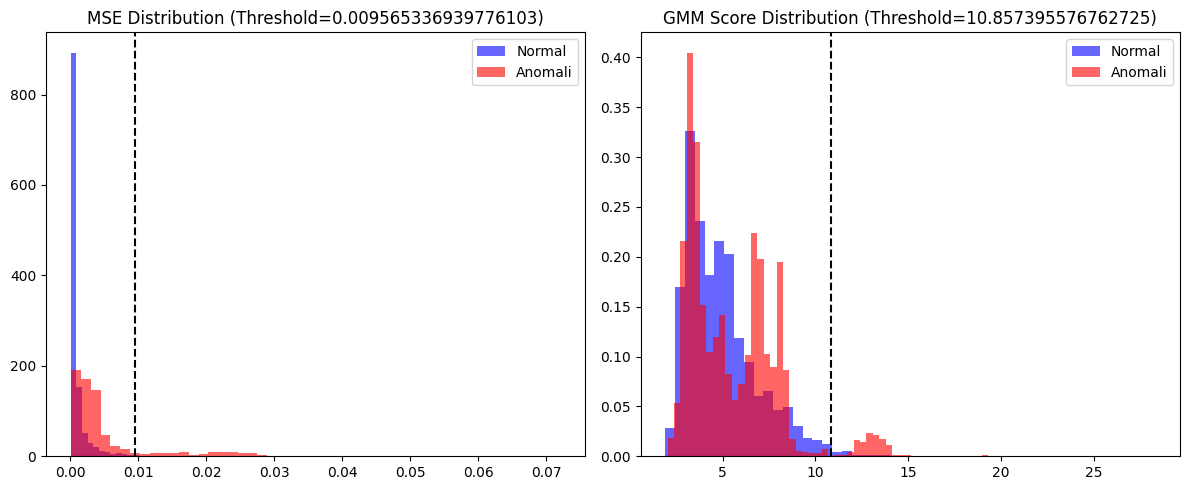

In [8]:
anom_sample = X_anomali[:2000] if len(X_anomali) > 2000 else X_test_anomali

anom_preds = cnn_vae.predict(anom_sample, verbose=0)
anom_mse = np.mean((anom_sample - anom_preds) ** 2, axis=(1, 2))

z_anom, _, _ = encoder.predict(anom_sample, verbose=0)
anom_gmm = -gmm.score_samples(z_anom)

val_preds = cnn_vae.predict(X_val_normal, verbose=0)
val_mse = np.mean((X_val_normal - val_preds) ** 2, axis=(1, 2))

z_val, _, _ = encoder.predict(X_val_normal, verbose=0)
val_gmm = -gmm.score_samples(z_val)

thresh_mse = AUTO_MSE_THRESHOLD
thresh_gmm = AUTO_GMM_THRESHOLD

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(val_mse, bins=50, density=True, alpha=0.6, label="Normal", color="blue")
plt.hist(anom_mse, bins=50, density=True, alpha=0.6, label="Anomali", color="red")
plt.axvline(thresh_mse, linestyle="--", color="black")
plt.title(f"MSE Distribution (Threshold={thresh_mse})")
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(val_gmm, bins=50, density=True, alpha=0.6, label="Normal", color="blue")
plt.hist(anom_gmm, bins=50, density=True, alpha=0.6, label="Anomali", color="red")
plt.axvline(thresh_gmm, linestyle="--", color="black")
plt.title(f"GMM Score Distribution (Threshold={thresh_gmm})")
plt.legend()

plt.tight_layout()
plt.show()

In [9]:
# Normal validation reconstruction
val_preds = cnn_vae.predict(X_val_normal, verbose=0)
val_mse = np.mean(np.square(X_val_normal - val_preds), axis=(1,2))

# Normal validation latent
z_val, _, _ = encoder.predict(X_val_normal, verbose=0)
val_gmm = -gmm.score_samples(z_val)

In [10]:
def normalize(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

val_mse_n = normalize(val_mse)
val_gmm_n = normalize(val_gmm)

In [11]:
ALPHA = 0.5
BETA  = 0.5

val_ensemble_score = ALPHA * val_mse_n + BETA * val_gmm_n

In [12]:
ENSEMBLE_PERCENTILE = 99
ensemble_threshold = np.percentile(val_ensemble_score, ENSEMBLE_PERCENTILE)

print("Ensemble threshold:", ensemble_threshold)

Ensemble threshold: 0.25041976791975795


In [13]:
anom_preds = cnn_vae.predict(X_anomali, verbose=0)
anom_mse = np.mean(np.square(X_anomali - anom_preds), axis=(1,2))

z_anom, _, _ = encoder.predict(X_anomali, verbose=0)
anom_gmm = -gmm.score_samples(z_anom)

anom_mse_n = normalize(anom_mse)
anom_gmm_n = normalize(anom_gmm)

anom_ensemble_score = ALPHA * anom_mse_n + BETA * anom_gmm_n

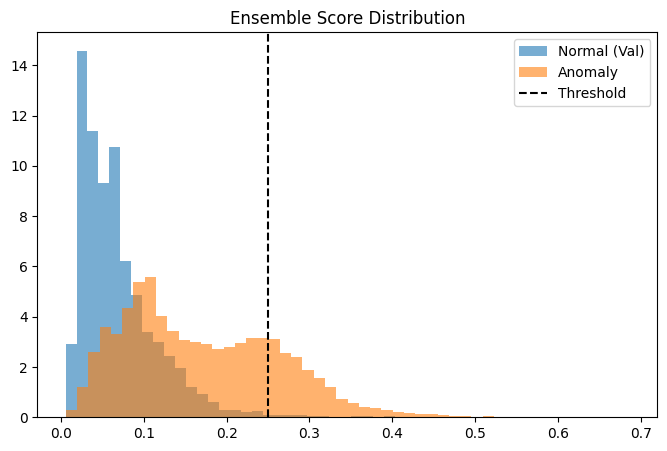

In [14]:
plt.figure(figsize=(8,5))
plt.hist(val_ensemble_score, bins=50, alpha=0.6, label="Normal (Val)", density=True)
plt.hist(anom_ensemble_score, bins=50, alpha=0.6, label="Anomaly", density=True)
plt.axvline(ensemble_threshold, color="black", linestyle="--", label="Threshold")
plt.title("Ensemble Score Distribution")
plt.legend()
plt.show()

In [15]:
is_anomaly = anom_ensemble_score > ensemble_threshold
print("Yakalanan anomaliler:", np.sum(is_anomaly))

Yakalanan anomaliler: 4099


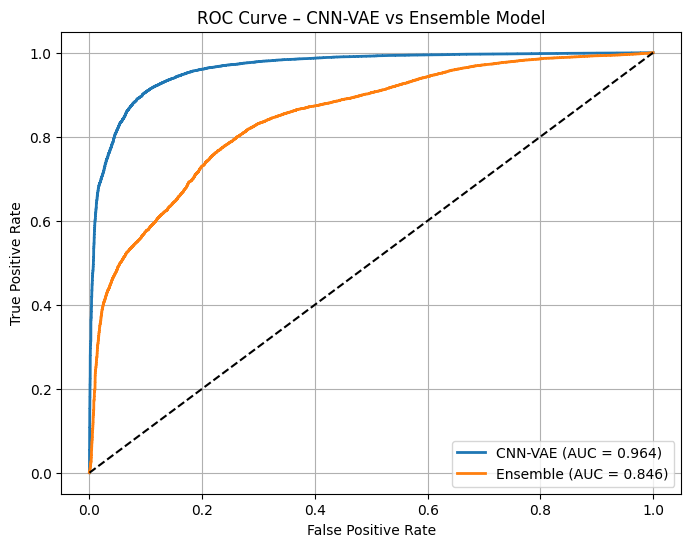

In [16]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_true = np.concatenate([
    np.zeros(len(val_ensemble_score)),
    np.ones(len(anom_ensemble_score))
])

y_score_ensemble = np.concatenate([
    val_ensemble_score,
    anom_ensemble_score
])

y_score_vae = np.concatenate([
    val_mse,
    anom_mse
])

fpr_ens, tpr_ens, _ = roc_curve(y_true, y_score_ensemble)
auc_ens = auc(fpr_ens, tpr_ens)

fpr_vae, tpr_vae, _ = roc_curve(y_true, y_score_vae)
auc_vae = auc(fpr_vae, tpr_vae)

plt.figure(figsize=(8,6))
plt.plot(fpr_vae, tpr_vae, label=f"CNN-VAE (AUC = {auc_vae:.3f})", linewidth=2)
plt.plot(fpr_ens, tpr_ens, label=f"Ensemble (AUC = {auc_ens:.3f})", linewidth=2)
plt.plot([0,1], [0,1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – CNN-VAE vs Ensemble Model")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
val_preds = cnn_vae.predict(X_val_normal, verbose=0)
val_mse = np.mean(np.square(X_val_normal - val_preds), axis=(1,2))

T1 = float(np.percentile(val_mse, 99.0))
T2 = float(np.percentile(val_mse, 99.9))

print("T1 (Anomaly threshold):", T1)
print("T2 (High-confidence anomaly threshold):", T2)

T1 (Anomaly threshold): 0.009597696123936747
T2 (High-confidence anomaly threshold): 0.023311390763919644


In [18]:
test_preds = cnn_vae.predict(X_anomali, verbose=0)
test_mse = np.mean(np.square(X_anomali - test_preds), axis=(1,2))

y_pred_3class = np.zeros(len(test_mse), dtype=int)
y_pred_3class[test_mse > T1] = 1
y_pred_3class[test_mse > T2] = 2

unique, counts = np.unique(y_pred_3class, return_counts=True)
print(dict(zip(unique, counts)))

{0: 7543, 1: 7536, 2: 3778}


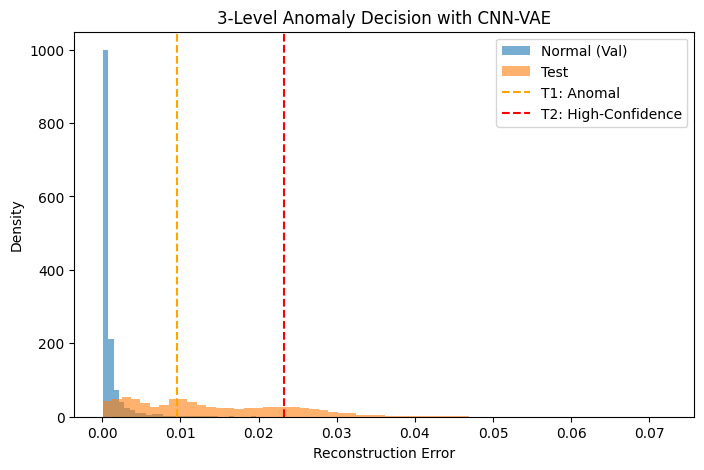

In [19]:
plt.figure(figsize=(8,5))
plt.hist(val_mse, bins=60, alpha=0.6, label="Normal (Val)", density=True)
plt.hist(test_mse, bins=60, alpha=0.6, label="Test", density=True)

plt.axvline(T1, color="orange", linestyle="--", label="T1: Anomal")
plt.axvline(T2, color="red", linestyle="--", label="T2: High-Confidence")

plt.legend()
plt.title("3-Level Anomaly Decision with CNN-VAE")
plt.xlabel("Reconstruction Error")
plt.ylabel("Density")
plt.show()

In [20]:
# High-confidence anomaliler (class = 2)
high_conf_idx = np.where(y_pred_3class == 2)[0]

X_high_conf = X_anomali[high_conf_idx]

print("High-confidence anomal sayısı:", X_high_conf.shape[0])

High-confidence anomal sayısı: 3778


In [21]:
z_mean_hc, _, _ = encoder.predict(X_high_conf, batch_size=256, verbose=0)

print("Latent shape:", z_mean_hc.shape)

Latent shape: (3778, 4)


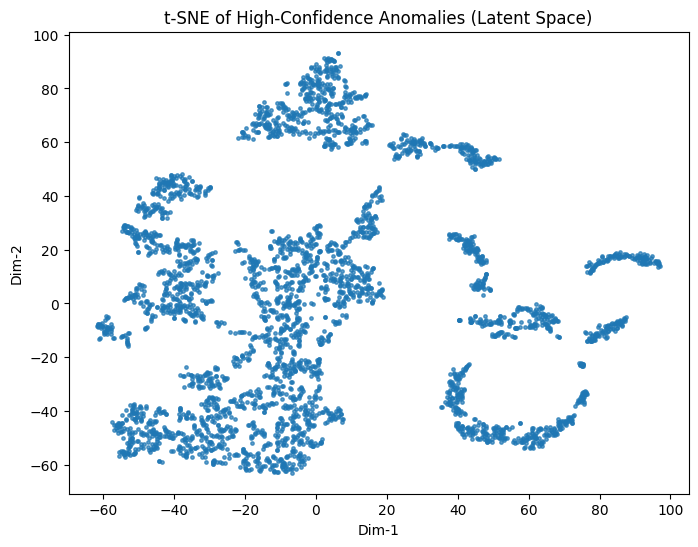

In [22]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    n_iter=2000,
    random_state=42
)

z_tsne = tsne.fit_transform(z_mean_hc)

plt.figure(figsize=(8,6))
plt.scatter(
    z_tsne[:,0],
    z_tsne[:,1],
    s=6,
    alpha=0.7
)
plt.title("t-SNE of High-Confidence Anomalies (Latent Space)")
plt.xlabel("Dim-1")
plt.ylabel("Dim-2")
plt.show()

In [23]:
from sklearn.mixture import GaussianMixture

# Küme sayısını önce tahmin edelim
gmm = GaussianMixture(
    n_components=4,
    covariance_type="full",
    random_state=42
)

cluster_labels = gmm.fit_predict(z_mean_hc)

np.unique(cluster_labels, return_counts=True)

(array([0, 1, 2, 3]), array([ 612, 2252,  163,  751]))

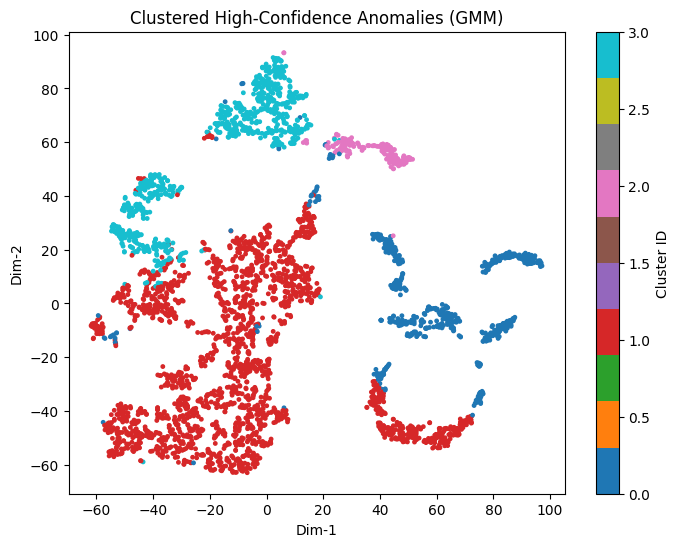

In [24]:
plt.figure(figsize=(8,6))
plt.scatter(
    z_tsne[:,0],
    z_tsne[:,1],
    c=cluster_labels,
    cmap="tab10",
    s=6
)
plt.title("Clustered High-Confidence Anomalies (GMM)")
plt.xlabel("Dim-1")
plt.ylabel("Dim-2")
plt.colorbar(label="Cluster ID")
plt.show()

In [25]:
unique, counts = np.unique(cluster_labels, return_counts=True)
dict(zip(unique, counts))

{0: 612, 1: 2252, 2: 163, 3: 751}

In [26]:
hc_idx = test_mse > T2   

In [27]:
z_test, _, _ = encoder.predict(X_anomali, batch_size=256, verbose=0)
test_gmm = -gmm.score_samples(z_test)

In [28]:
hc_mse = test_mse[hc_idx]
hc_gmm = test_gmm[hc_idx]

In [29]:
for c in np.unique(cluster_labels):
    idx = cluster_labels == c
    print(
        f"Cluster {c} | "
        f"MSE mean: {hc_mse[idx].mean():.4f} | "
        f"GMM mean: {hc_gmm[idx].mean():.4f} | "
        f"Count: {idx.sum()}"
    )

Cluster 0 | MSE mean: 0.0286 | GMM mean: 6.8682 | Count: 612
Cluster 1 | MSE mean: 0.0279 | GMM mean: 1.9808 | Count: 2252
Cluster 2 | MSE mean: 0.0289 | GMM mean: 8.6992 | Count: 163
Cluster 3 | MSE mean: 0.0328 | GMM mean: 1.6604 | Count: 751


In [30]:
print("High-conf anomalies:", hc_idx.sum())
print("Cluster labels:", len(cluster_labels))

High-conf anomalies: 3778
Cluster labels: 3778


In [31]:
# High-confidence anomalileri al
X_hc = X_anomali[hc_idx]

# Cluster-2 maskesi (SADECE high-conf içinde)
cluster2_mask = cluster_labels == 2

X_cluster2 = X_hc[cluster2_mask]

print("Cluster-2 beat sayısı:", X_cluster2.shape[0])

Cluster-2 beat sayısı: 163


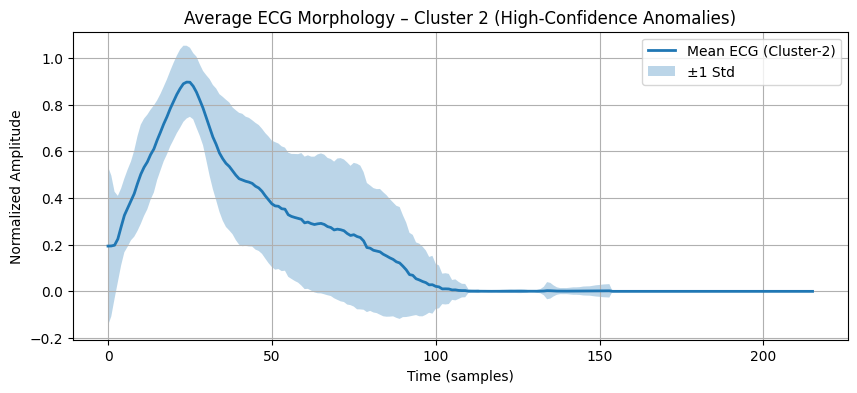

In [32]:
mean_beat = X_cluster2.mean(axis=0).squeeze()
std_beat  = X_cluster2.std(axis=0).squeeze()

plt.figure(figsize=(10,4))
plt.plot(mean_beat, label="Mean ECG (Cluster-2)", linewidth=2)
plt.fill_between(
    range(len(mean_beat)),
    mean_beat - std_beat,
    mean_beat + std_beat,
    alpha=0.3,
    label="±1 Std"
)
plt.title("Average ECG Morphology – Cluster 2 (High-Confidence Anomalies)")
plt.xlabel("Time (samples)")
plt.ylabel("Normalized Amplitude")
plt.legend()
plt.grid(True)
plt.show()

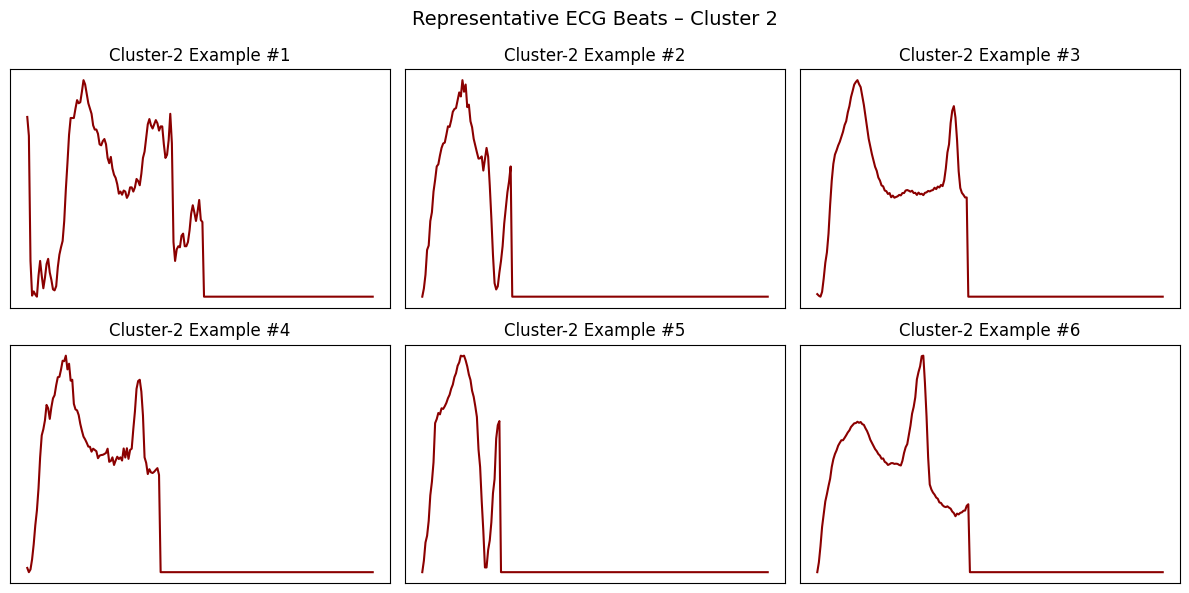

In [33]:
plt.figure(figsize=(12,6))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.plot(X_cluster2[i].squeeze(), color="darkred")
    plt.title(f"Cluster-2 Example #{i+1}")
    plt.xticks([])
    plt.yticks([])

plt.suptitle("Representative ECG Beats – Cluster 2", fontsize=14)
plt.tight_layout()
plt.show()

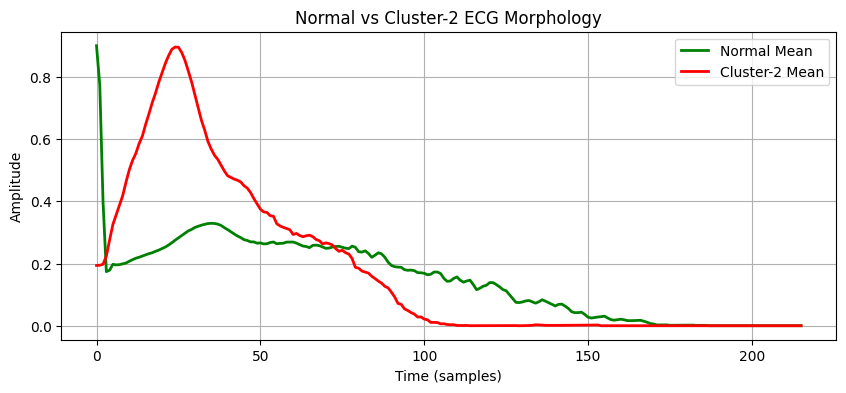

In [34]:
X_normal_sample = X_train_normal[:len(mean_beat)]

mean_normal = X_normal_sample.mean(axis=0).squeeze()

plt.figure(figsize=(10,4))
plt.plot(mean_normal, label="Normal Mean", linewidth=2, color="green")
plt.plot(mean_beat, label="Cluster-2 Mean", linewidth=2, color="red")
plt.title("Normal vs Cluster-2 ECG Morphology")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

In [35]:
def get_cluster_beats(cluster_id, cluster_labels, hc_idx, X_test_anomali):
    hc_beats = X_test_anomali[hc_idx]
    idx = cluster_labels == cluster_id
    return hc_beats[idx]

In [36]:
def plot_mean_morphology(beats, title):
    mean_beat = beats.mean(axis=0).squeeze()
    std_beat = beats.std(axis=0).squeeze()

    plt.figure(figsize=(12,5))
    plt.plot(mean_beat, label="Mean ECG")
    plt.fill_between(
        np.arange(len(mean_beat)),
        mean_beat - std_beat,
        mean_beat + std_beat,
        alpha=0.3,
        label="±1 Std"
    )
    plt.title(title)
    plt.xlabel("Time (samples)")
    plt.ylabel("Normalized Amplitude")
    plt.legend()
    plt.grid(True)
    plt.show()

In [37]:
def plot_examples(beats, cluster_id, n=6):
    idx = np.random.choice(len(beats), n, replace=False)
    plt.figure(figsize=(12,6))
    for i, j in enumerate(idx):
        plt.subplot(2, 3, i+1)
        plt.plot(beats[j].squeeze())
        plt.title(f"Cluster-{cluster_id} Example #{i+1}")
        plt.xticks([])
        plt.yticks([])
    plt.suptitle(f"Representative ECG Beats – Cluster {cluster_id}")
    plt.tight_layout()
    plt.show()

Cluster-0 beat sayısı: 612


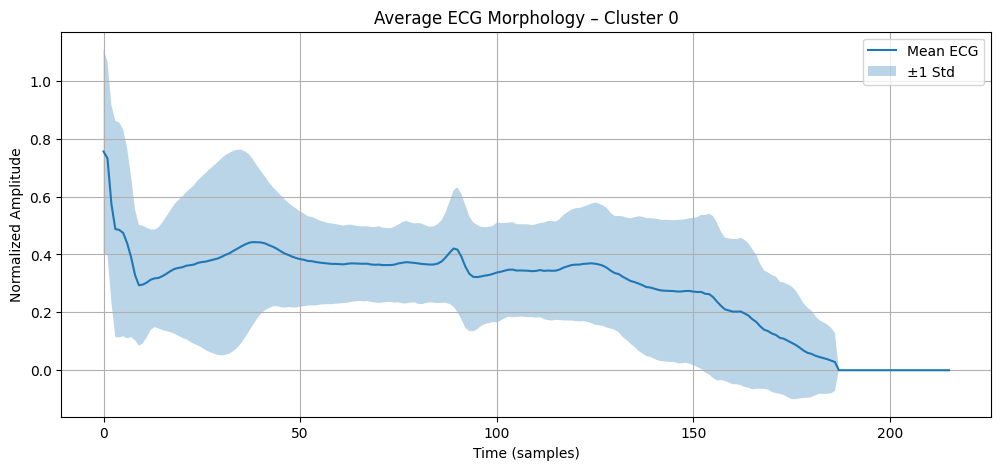

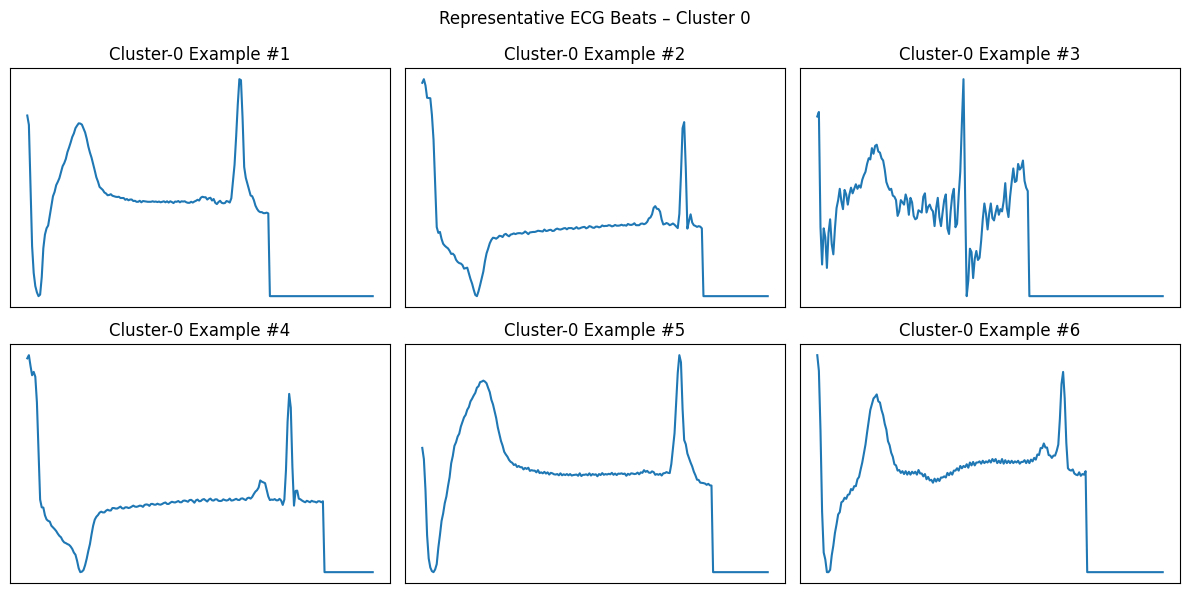

In [38]:
beats_c0 = get_cluster_beats(0, cluster_labels, hc_idx, X_anomali)
print("Cluster-0 beat sayısı:", len(beats_c0))
plot_mean_morphology(beats_c0, "Average ECG Morphology – Cluster 0")
plot_examples(beats_c0, 0)

Cluster-1 beat sayısı: 2252


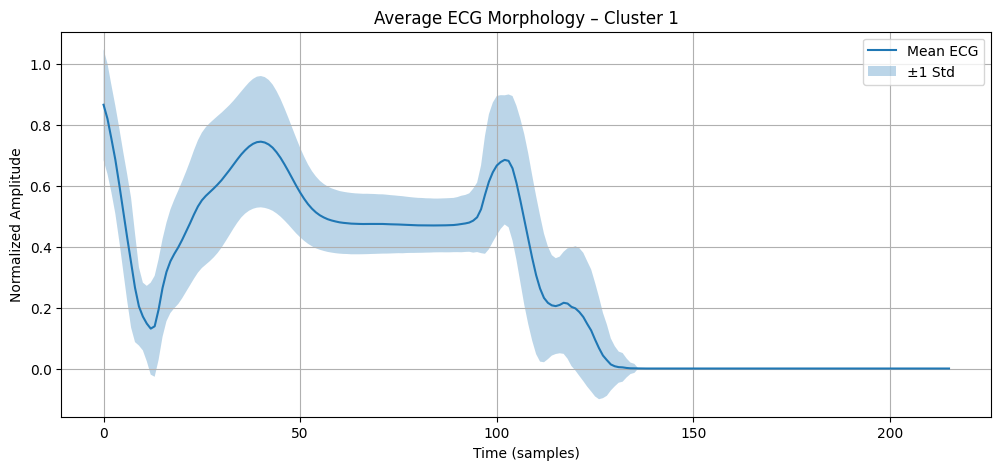

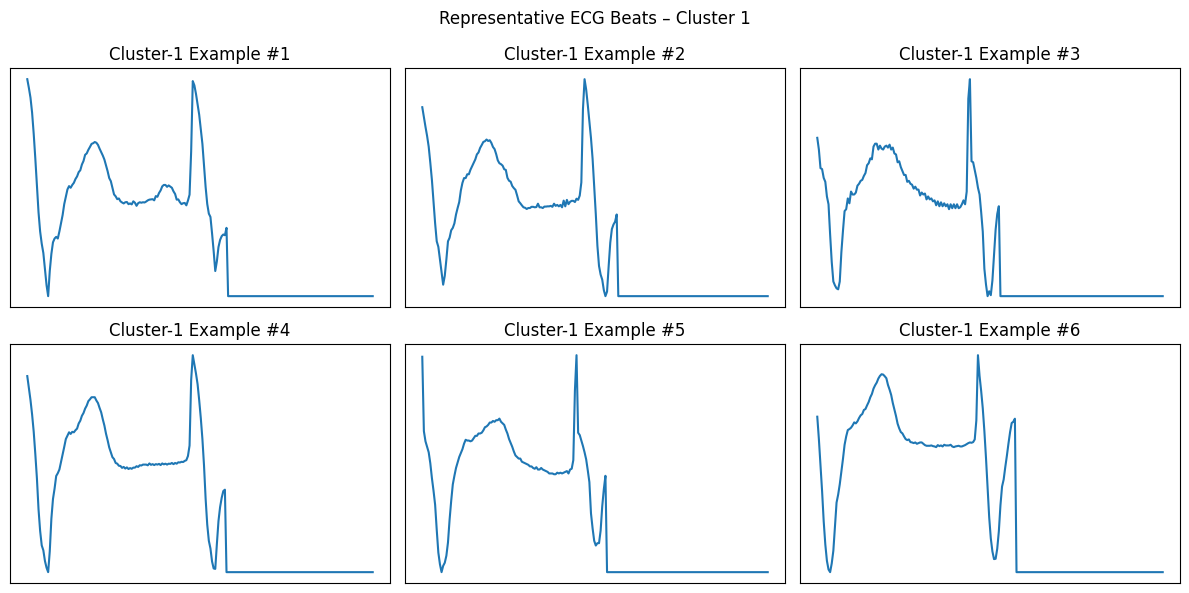

In [39]:
beats_c1 = get_cluster_beats(1, cluster_labels, hc_idx, X_anomali)
print("Cluster-1 beat sayısı:", len(beats_c1))
plot_mean_morphology(beats_c1, "Average ECG Morphology – Cluster 1")
plot_examples(beats_c1, 1)

Cluster-3 beat sayısı: 751


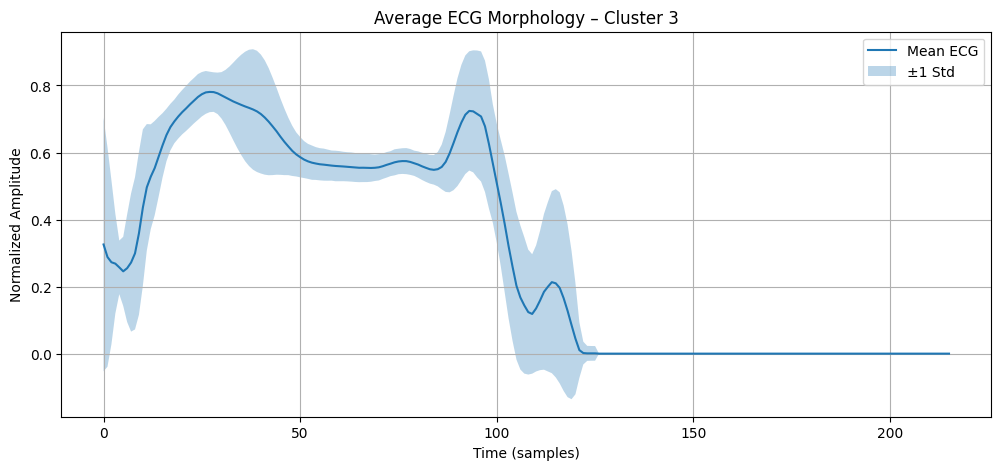

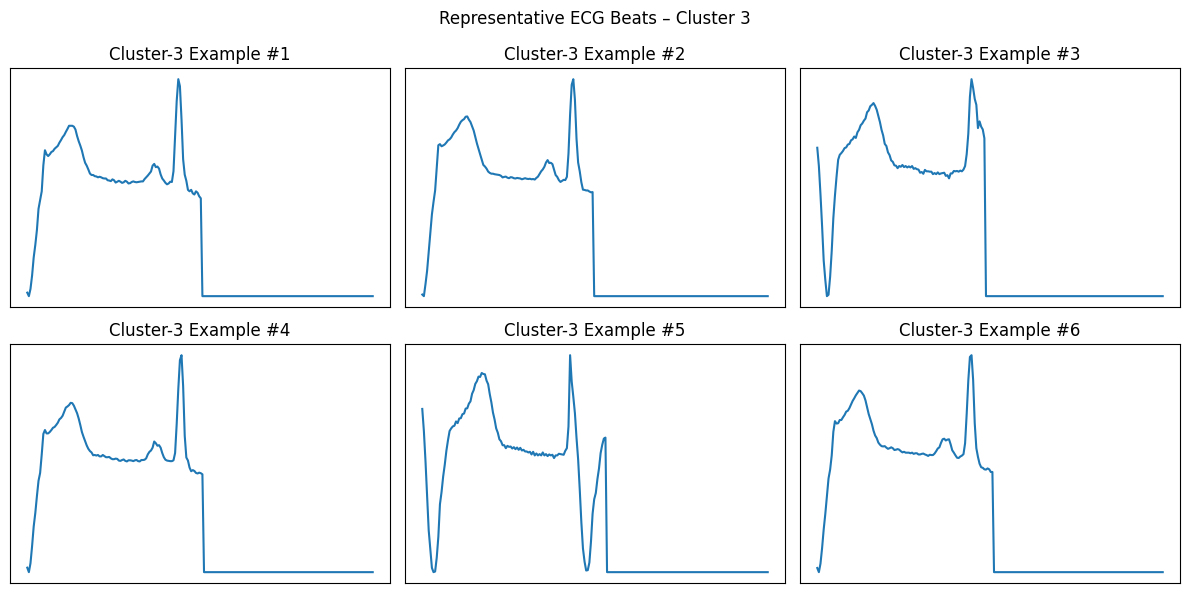

In [40]:
beats_c3 = get_cluster_beats(3, cluster_labels, hc_idx, X_anomali)
print("Cluster-3 beat sayısı:", len(beats_c3))
plot_mean_morphology(beats_c3, "Average ECG Morphology – Cluster 3")
plot_examples(beats_c3, 3)

In [41]:
import numpy as np
from scipy.stats import entropy

def extract_ecg_features(beats):
    if beats.ndim == 3:
        beats = beats.squeeze(-1)

    features = []

    for beat in beats:
        beat = beat.flatten()

        # Peak values
        r_peak = np.max(beat)
        min_val = np.min(beat)
        ptp_amp = r_peak - min_val

        # QRS width (simple threshold-based)
        threshold = 0.5 * r_peak
        qrs_indices = np.where(beat >= threshold)[0]
        qrs_width = qrs_indices[-1] - qrs_indices[0] if len(qrs_indices) > 0 else 0

        # Energy & variance
        energy = np.sum(beat ** 2)
        variance = np.var(beat)

        # Entropy
        hist, _ = np.histogram(beat, bins=50, density=True)
        ent = entropy(hist + 1e-8)

        # Zero-crossing rate
        zero_crossings = np.sum(np.diff(np.sign(beat)) != 0)

        features.append([
            r_peak,
            ptp_amp,
            qrs_width,
            energy,
            variance,
            ent,
            zero_crossings
        ])

    return np.array(features)

In [42]:
# High-confidence anomalilerin kendisi
hc_beats = X_anomali[hc_idx]

# Cluster-2 maskesi (SADECE high-conf içinde)
c2_idx = cluster_labels == 2

# Asıl aradığımız şey
beats_c2 = hc_beats[c2_idx]

print("Cluster-2 beat sayısı:", beats_c2.shape[0])

Cluster-2 beat sayısı: 163


In [43]:
features_c2 = extract_ecg_features(beats_c2)

feature_names = [
    "R_peak",
    "Peak_to_Peak",
    "QRS_width",
    "Energy",
    "Variance",
    "Entropy",
    "Zero_Crossings"
]

In [44]:
print(beats_c2.shape)

(163, 216, 1)


In [45]:
import pandas as pd

df_c2 = pd.DataFrame(features_c2, columns=feature_names)

summary = df_c2.describe().T[["mean", "std", "min", "max"]]
print(summary)

                     mean        std       min         max
R_peak           1.000000   0.000000  1.000000    1.000000
Peak_to_Peak     1.000000   0.000000  1.000000    1.000000
QRS_width       55.012270  21.803553  6.000000  101.000000
Energy          26.870482   8.508554  5.716868   51.746021
Variance         0.087900   0.019635  0.025404    0.138826
Entropy          1.602209   0.402374  0.323348    3.015446
Zero_Crossings   2.619632   0.511698  1.000000    4.000000


In [46]:
import numpy as np

def extract_features(beats):
    """
    beats: (N, 216) numpy array
    return: (N, num_features)
    """

    features = []

    for beat in beats:
        beat = beat.flatten()

        # --- R-peak ---
        r_peak = np.max(beat)
        r_peak_idx = np.argmax(beat)

        # --- QRS width (basit ama etkili) ---
        threshold = 0.5 * r_peak
        qrs_region = np.where(beat > threshold)[0]
        qrs_width = qrs_region[-1] - qrs_region[0] if len(qrs_region) > 0 else 0

        # --- Enerji ---
        energy = np.sum(beat ** 2)

        # --- Varyans ---
        variance = np.var(beat)

        # --- Entropy ---
        hist, _ = np.histogram(beat, bins=20, density=True)
        hist = hist[hist > 0]
        entropy = -np.sum(hist * np.log(hist))

        # --- Zero crossing ---
        zero_crossings = np.sum(np.diff(np.sign(beat)) != 0)

        features.append([
            r_peak,
            r_peak_idx,
            qrs_width,
            energy,
            variance,
            entropy,
            zero_crossings
        ])

    return np.array(features)

In [47]:
feature_names = [
    "R_peak",
    "Peak_to_Peak",
    "QRS_width",
    "Energy",
    "Variance",
    "Entropy",
    "Zero_Crossings"
]

In [48]:
features_c2 = extract_features(beats_c2.squeeze())
df_c2 = pd.DataFrame(features_c2, columns=feature_names)

df_c2.describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
R_peak,1.000000,0.000000,1.000000,1.000000
Peak_to_Peak,30.748466,17.789005,0.000000,91.000000
QRS_width,54.975460,21.799295,6.000000,101.000000
Energy,26.870482,8.508554,5.716868,51.746021
Variance,0.087900,0.019635,0.025404,0.138826
Entropy,-32.598046,6.346635,-53.704414,-12.481122
Zero_Crossings,2.619632,0.511698,1.000000,4.000000


In [49]:
features_normal = extract_features(X_train_normal.squeeze())
df_normal = pd.DataFrame(features_normal, columns=feature_names)

In [50]:
df_normal.describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
R_peak,0.999968,0.002207,0.625786,1.000000
Peak_to_Peak,43.754986,49.032017,0.000000,186.000000
QRS_width,93.515332,27.492519,0.000000,186.000000
Energy,13.729948,13.461472,1.158800,102.853964
Variance,0.036198,0.023617,0.005224,0.233806
Entropy,-30.640430,5.601303,-57.556882,-8.393782
Zero_Crossings,3.057439,0.721475,1.000000,17.000000


In [51]:
df_c2["Group"] = "Cluster-2 (High-Conf Anomaly)"
df_normal["Group"] = "Normal"

In [52]:
df_all = pd.concat([df_normal, df_c2], ignore_index=True)

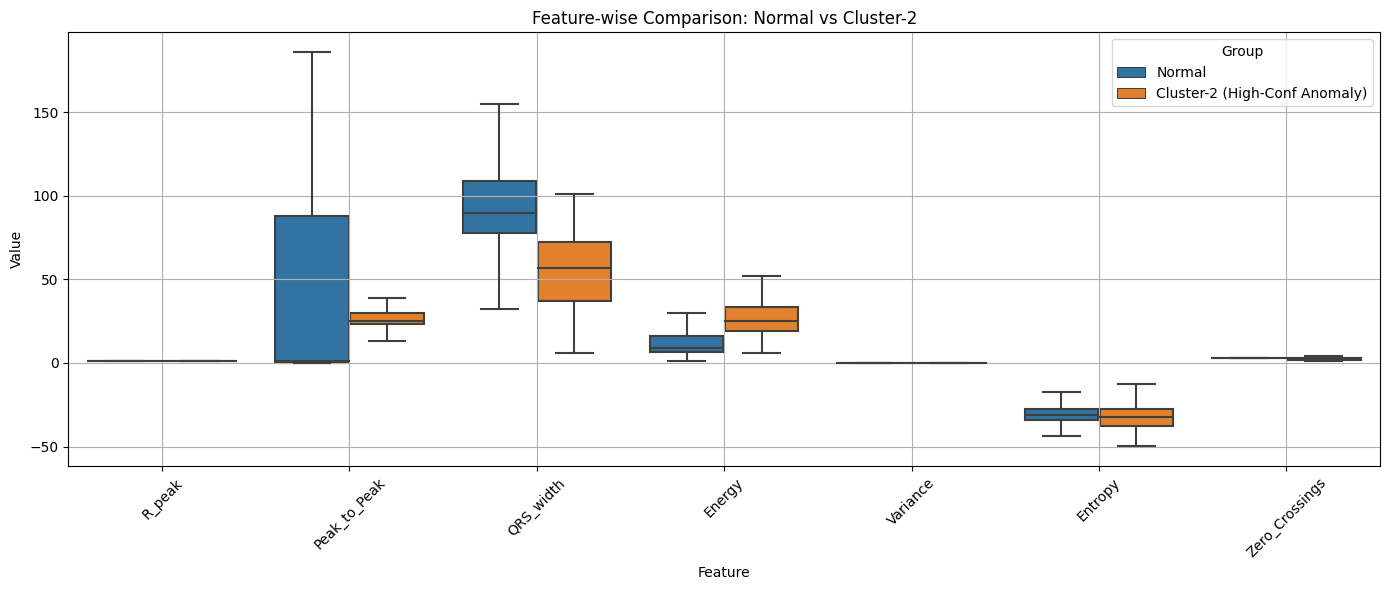

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
sns.boxplot(
    data=df_all.melt(id_vars="Group"),
    x="variable",
    y="value",
    hue="Group",
    showfliers=False
)

plt.title("Feature-wise Comparison: Normal vs Cluster-2")
plt.xlabel("Feature")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [54]:
 required = ["X_train_normal","X_test_anomali","hc_idx","cluster_labels"]
for r in required:
    print(r, "OK" if r in globals() else "MISSING")
print("X_train_normal:", getattr(globals().get("X_train_normal", None), "shape", None))
print("X_test_anomali:", getattr(globals().get("X_test_anomali", None), "shape", None))
print("hc_idx:", getattr(globals().get("hc_idx", None), "shape", None), "sum:", int(np.sum(hc_idx)) if "hc_idx" in globals() else None)
print("cluster_labels:", getattr(globals().get("cluster_labels", None), "shape", None))

X_train_normal OK
X_test_anomali MISSING
hc_idx OK
cluster_labels OK
X_train_normal: (81530, 216, 1)
X_test_anomali: None
hc_idx: (18857,) sum: 3778
cluster_labels: (3778,)


In [55]:
import numpy as np
import pandas as pd

def extract_features(beat_1d):
    x = np.asarray(beat_1d).reshape(-1)
    r_peak = float(np.max(x))
    ptp = float(np.max(x) - np.min(x))
    energy = float(np.sum(x**2))
    var = float(np.var(x))
    eps = 1e-12
    p = np.abs(x) + eps
    p = p / np.sum(p)
    entropy = float(-np.sum(p * np.log(p)))
    zc = int(np.sum(np.diff(np.sign(x - np.mean(x))) != 0))
    qrs_width = int(np.sum(x > (np.mean(x) + 0.25*np.std(x))))  # basit/robust proxy

    return [r_peak, ptp, qrs_width, energy, var, entropy, zc]

feature_names = ["R_peak","Peak_to_Peak","QRS_width","Energy","Variance","Entropy","Zero_Crossings"]

def get_cluster_beats(cluster_id, cluster_labels, hc_idx, X_test_anomali):
    hc_beats = X_test_anomali[hc_idx]          # (N_hc, 216, 1)
    mask = (cluster_labels == cluster_id)      # (N_hc,)
    return hc_beats[mask]                      # (N_cluster, 216, 1)


===== CLUSTER 0 =====
beat sayısı: 612


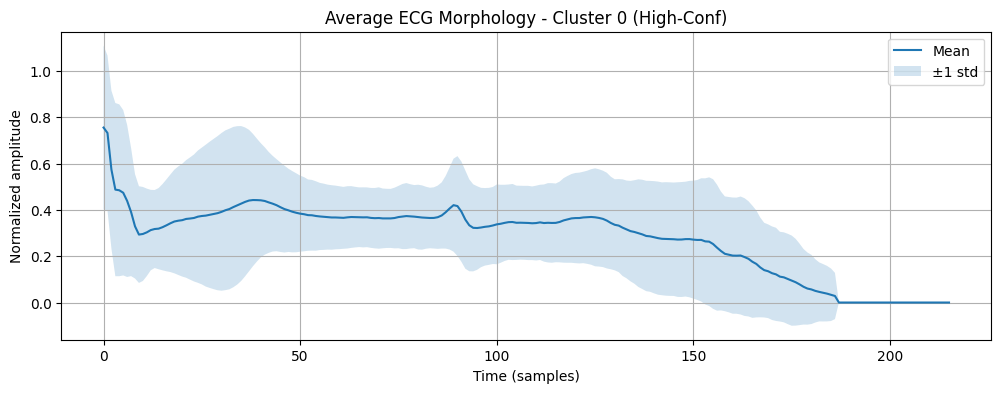

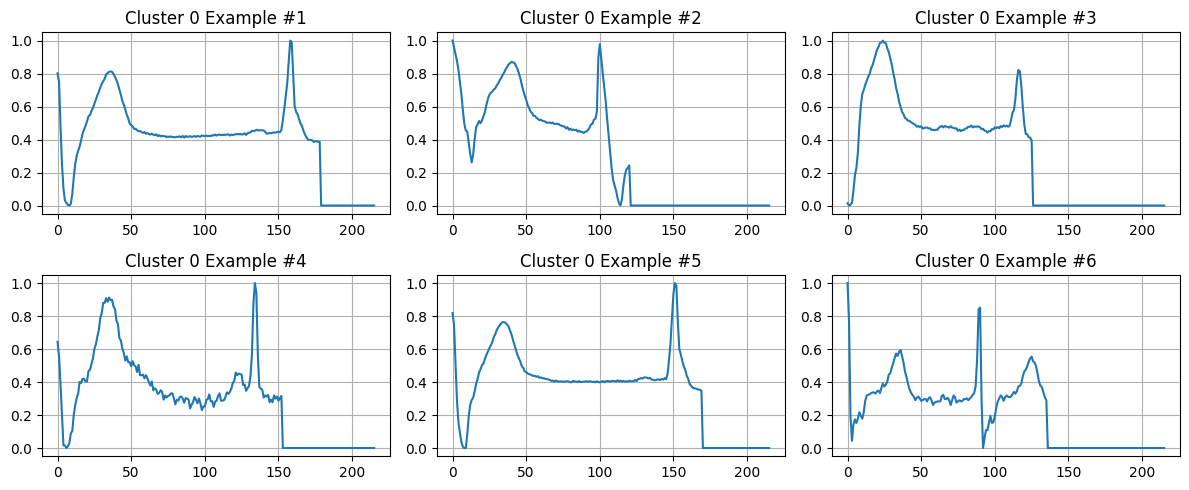

,Normal_R_peak,Normal_Peak_to_Peak,Normal_QRS_width,Normal_Energy,Normal_Variance,Normal_Entropy,Normal_Zero_Crossings,C0_R_peak,C0_Peak_to_Peak,C0_QRS_width,C0_Energy,C0_Variance,C0_Entropy,C0_Zero_Crossings
mean,0.999992,0.999992,71.470600,13.773742,0.036286,4.421101,7.56300,0.999869,0.999869,98.410131,30.546537,0.053860,4.876488,4.759804
std,0.000594,0.000594,27.222148,13.580203,0.023956,0.326590,5.29706,0.002638,0.002638,28.134062,16.861288,0.023322,0.318681,4.033755



===== CLUSTER 1 =====
beat sayısı: 2252


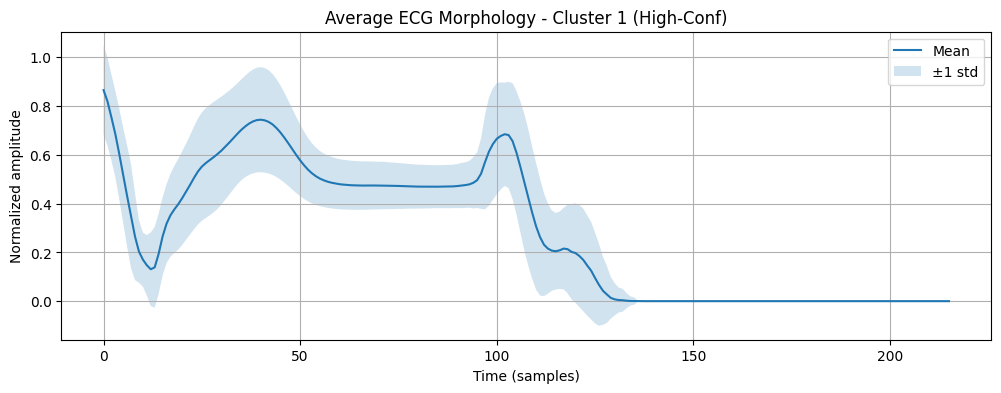

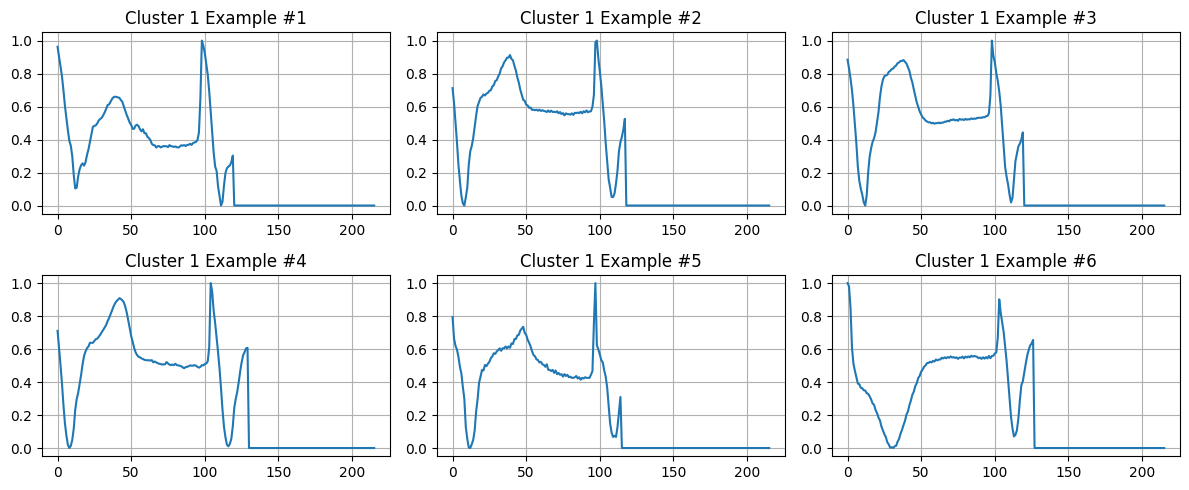

,Normal_R_peak,Normal_Peak_to_Peak,Normal_QRS_width,Normal_Energy,Normal_Variance,Normal_Entropy,Normal_Zero_Crossings,C1_R_peak,C1_Peak_to_Peak,C1_QRS_width,C1_Energy,C1_Variance,C1_Entropy,C1_Zero_Crossings
mean,0.999992,0.999992,71.470600,13.773742,0.036286,4.421101,7.56300,1.0,1.0,98.957371,36.737793,0.087906,4.685408,4.521758
std,0.000594,0.000594,27.222148,13.580203,0.023956,0.326590,5.29706,0.0,0.0,5.563570,10.207656,0.020692,0.073560,0.945877



===== CLUSTER 2 =====
beat sayısı: 163


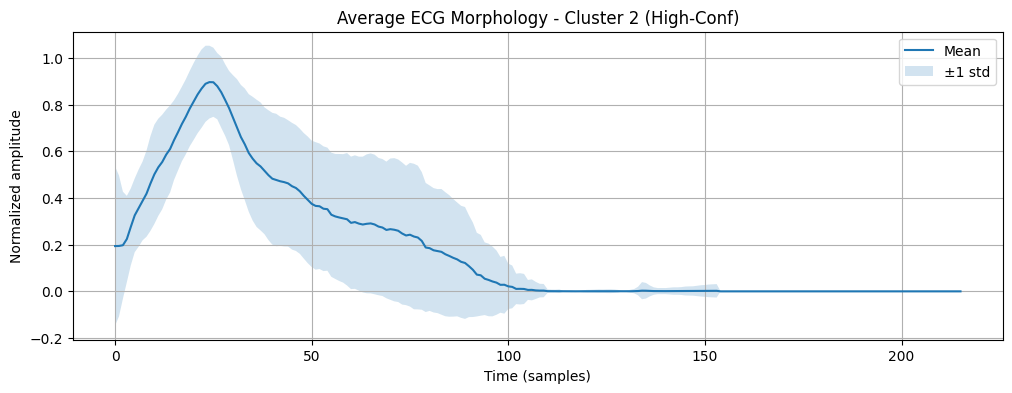

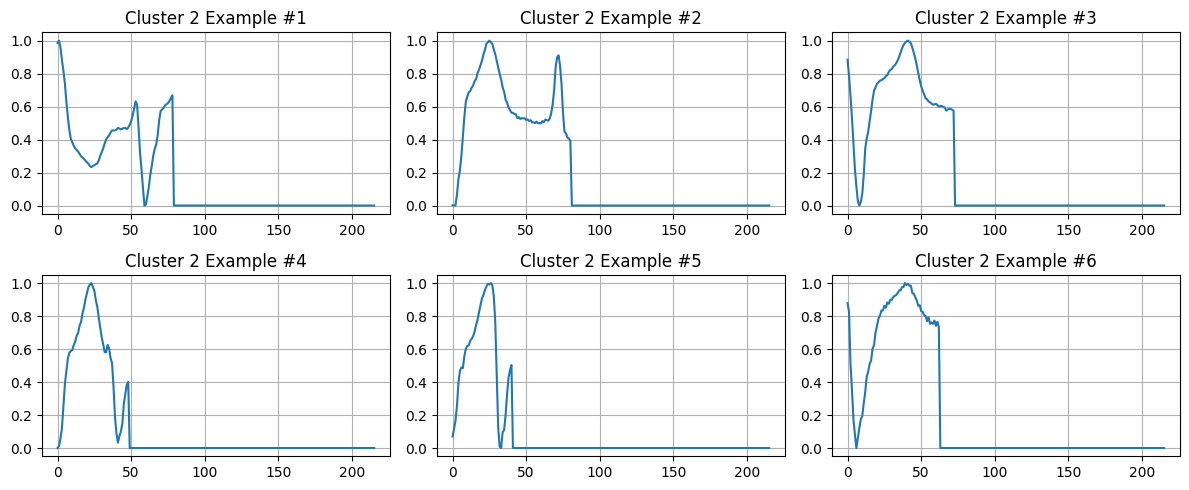

,Normal_R_peak,Normal_Peak_to_Peak,Normal_QRS_width,Normal_Energy,Normal_Variance,Normal_Entropy,Normal_Zero_Crossings,C2_R_peak,C2_Peak_to_Peak,C2_QRS_width,C2_Energy,C2_Variance,C2_Entropy,C2_Zero_Crossings
mean,0.999992,0.999992,71.470600,13.773742,0.036286,4.421101,7.56300,1.0,1.0,60.049080,26.870482,0.087900,4.055095,3.319018
std,0.000594,0.000594,27.222148,13.580203,0.023956,0.326590,5.29706,0.0,0.0,19.987899,8.508554,0.019635,0.377699,1.477007



===== CLUSTER 3 =====
beat sayısı: 751


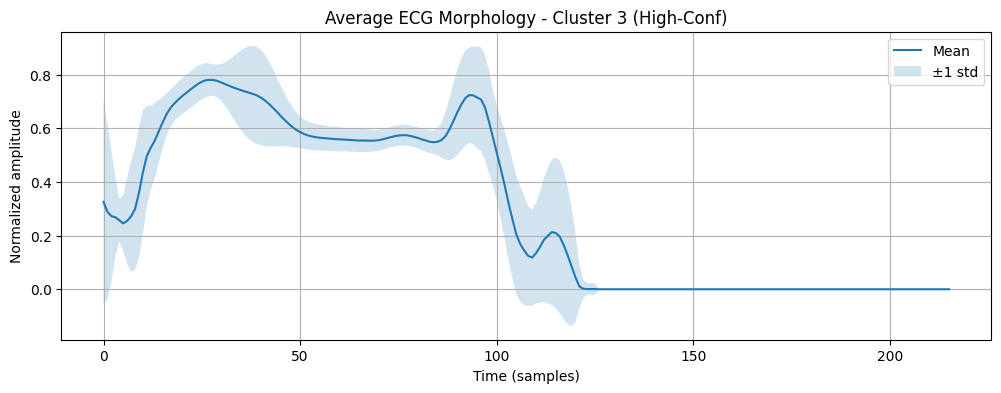

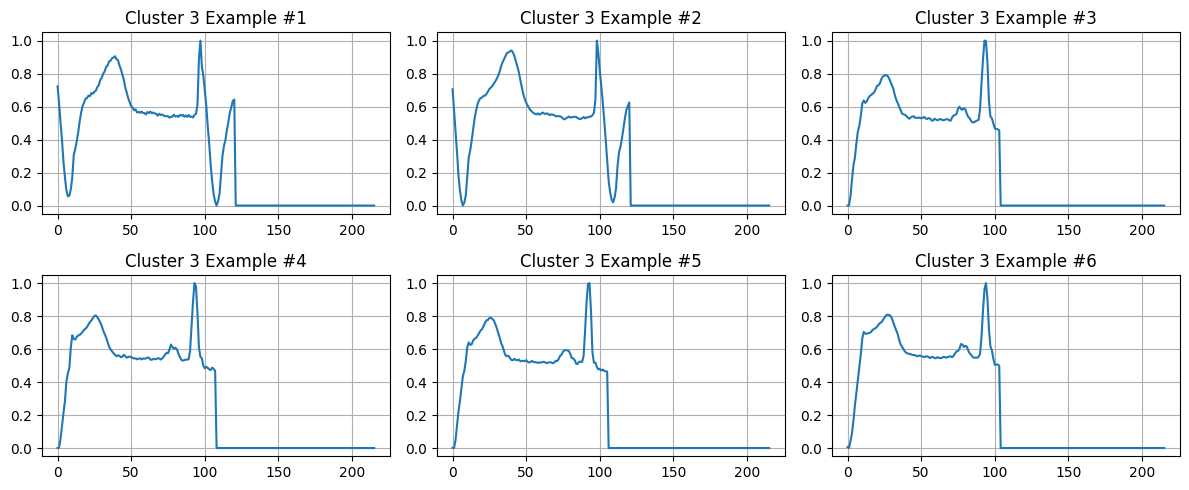

,Normal_R_peak,Normal_Peak_to_Peak,Normal_QRS_width,Normal_Energy,Normal_Variance,Normal_Entropy,Normal_Zero_Crossings,C3_R_peak,C3_Peak_to_Peak,C3_QRS_width,C3_Energy,C3_Variance,C3_Entropy,C3_Zero_Crossings
mean,0.999992,0.999992,71.470600,13.773742,0.036286,4.421101,7.56300,1.0,1.0,99.166445,41.349739,0.102441,4.636952,3.219707
std,0.000594,0.000594,27.222148,13.580203,0.023956,0.326590,5.29706,0.0,0.0,2.760723,5.635559,0.012363,0.041016,1.455449


In [56]:
import matplotlib.pyplot as plt

def plot_mean_morphology(beats, title):
    if len(beats) == 0:
        print(title, "-> boş")
        return
    x = beats.squeeze(-1)  # (N, 216)
    m = x.mean(axis=0)
    s = x.std(axis=0)

    plt.figure(figsize=(12,4))
    plt.plot(m, label="Mean")
    plt.fill_between(np.arange(len(m)), m-s, m+s, alpha=0.2, label="±1 std")
    plt.title(title)
    plt.xlabel("Time (samples)")
    plt.ylabel("Normalized amplitude")
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_examples(beats, title, n=6, seed=42):
    if len(beats) == 0:
        return
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(beats), size=min(n, len(beats)), replace=False)
    x = beats[idx].squeeze(-1)

    rows = 2
    cols = int(np.ceil(len(idx)/rows))
    plt.figure(figsize=(4*cols, 5))
    for i, b in enumerate(x):
        plt.subplot(rows, cols, i+1)
        plt.plot(b)
        plt.title(f"{title} #{i+1}")
        plt.grid(True)
    plt.tight_layout()
    plt.show()

def features_df(beats):
    x = beats.squeeze(-1)
    feats = np.array([extract_features(b) for b in x], dtype=float)
    return pd.DataFrame(feats, columns=feature_names)

# Normal referans (küçük sample yeter)
normal_ref = X_train_normal[:min(5000, len(X_train_normal))]
df_norm = features_df(normal_ref)

for c in sorted(np.unique(cluster_labels)):
    beats_c = get_cluster_beats(c, cluster_labels, hc_idx, X_anomali)
    print(f"\n===== CLUSTER {c} =====")
    print("beat sayısı:", len(beats_c))

    plot_mean_morphology(beats_c, f"Average ECG Morphology - Cluster {c} (High-Conf)")
    plot_examples(beats_c, f"Cluster {c} Example", n=6)

    df_c = features_df(beats_c)
    summary = pd.concat([
        df_norm.describe().loc[["mean","std"]].add_prefix("Normal_"),
        df_c.describe().loc[["mean","std"]].add_prefix(f"C{c}_")
    ], axis=1)

    display(summary)

In [57]:
X_hc = X_anomali[hc_idx]                 # (N_hc, 216, 1)
y_hc = cluster_labels.astype(int)             # (N_hc,)

print("X_hc:", X_hc.shape, "y_hc:", y_hc.shape)
print("class counts:", dict(zip(*np.unique(y_hc, return_counts=True))))

X_hc: (3778, 216, 1) y_hc: (3778,)
class counts: {0: 612, 1: 2252, 2: 163, 3: 751}


In [58]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, Model

X_tr, X_te, y_tr, y_te = train_test_split(
    X_hc, y_hc, test_size=0.2, random_state=42, stratify=y_hc
)

num_classes = len(np.unique(y_hc))

inp = layers.Input(shape=X_hc.shape[1:])
x = layers.Conv1D(32, 5, padding="same", activation="relu")(inp)
x = layers.MaxPool1D(2)(x)
x = layers.Conv1D(64, 5, padding="same", activation="relu")(x)
x = layers.MaxPool1D(2)(x)
x = layers.Conv1D(128, 3, padding="same", activation="relu")(x)
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(0.3)(x)
out = layers.Dense(num_classes, activation="softmax")(x)

clf = Model(inp, out)
clf.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"])

hist = clf.fit(X_tr, y_tr, validation_split=0.15, epochs=50, batch_size=256, verbose=1)

y_pred = np.argmax(clf.predict(X_te, verbose=0), axis=1)
print(classification_report(y_te, y_pred, digits=4))
print("Confusion:\n", confusion_matrix(y_te, y_pred))

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 243ms/step - accuracy: 0.4789 - loss: 1.3272 - val_accuracy: 0.5639 - val_loss: 1.1421
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6034 - loss: 1.0883 - val_accuracy: 0.5639 - val_loss: 1.1149
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6100 - loss: 1.0279 - val_accuracy: 0.5639 - val_loss: 1.0934
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5973 - loss: 1.0515 - val_accuracy: 0.5639 - val_loss: 1.0954
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6142 - loss: 1.0174 - val_accuracy: 0.5639 - val_loss: 1.0935
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6088 - loss: 1.0302 - val_accuracy: 0.5639 - val_loss: 1.0910
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6060 - loss: 1.0319 - val_accuracy: 0.5639 - val_loss: 1.0858
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6082 - loss: 1.0209 - val_accuracy: 0.5639 - 

In [59]:
def predict_cluster_with_confidence(beat_216x1, model=clf):
    p = model.predict(beat_216x1[None, ...], verbose=0)[0]
    cid = int(np.argmax(p))
    conf = float(np.max(p))
    return cid, conf, p

# örnek
cid, conf, p = predict_cluster_with_confidence(X_hc[0])
print("pred cluster:", cid, "conf:", conf, "probs:", p)

pred cluster: 0 conf: 0.9029972553253174 probs: [9.0299726e-01 9.6626811e-02 9.6352942e-06 3.6618992e-04]


In [60]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

# 1) Gerçek etiketleri (y_true) X_test_anomali sırasıyla hizala
df_train = pd.read_csv('/kaggle/input/heartbeat/mitbih_train.csv', header=None)
df_test  = pd.read_csv('/kaggle/input/heartbeat/mitbih_test.csv',  header=None)

def get_anom_labels(df):
    # label sütunu: 187
    y = df[df[187] != 0][187].astype(int).values
    return y

# Önce concat (senin ilk koduna daha yakın)
y_anom_all = get_anom_labels(pd.concat([df_train, df_test], axis=0))

# Eğer uzunluk tutmazsa test-only'e düş (daha doğru eval zaten test-only)
if len(y_anom_all) != X_anomali.shape[0]:
    y_anom_all = get_anom_labels(df_test)

# Son kontrol
assert len(y_anom_all) == X_anomali.shape[0], (
    f"Label uzunluğu ({len(y_anom_all)}) ile X_test_anomali ({X_anomali.shape[0]}) eşleşmiyor."
)

# 2) High-confidence mask ile filtrele
y_true_hc = y_anom_all[hc_idx]              # MIT-BIH gerçek sınıf (1..4)
y_pred_cluster = np.array(cluster_labels)   # GMM cluster (0..3)

assert len(y_true_hc) == len(y_pred_cluster), (
    f"HC label ({len(y_true_hc)}) ile cluster_labels ({len(y_pred_cluster)}) eşleşmiyor."
)

# 3) Confusion (Cluster x TrueLabel)
true_labels = np.sort(np.unique(y_true_hc))          # 1..4
cluster_ids = np.sort(np.unique(y_pred_cluster))     # 0..3

cm = confusion_matrix(y_true_hc, y_pred_cluster, labels=true_labels)
cm_df = pd.DataFrame(cm, index=[f"True_{t}" for t in true_labels],
                        columns=[f"Clus_{c}" for c in cluster_ids])

print("Confusion Matrix (TrueLabel x Cluster):")
display(cm_df)

# 4) Her cluster'ın hangi gerçek label'a en çok denk geldiğini bul (majority mapping)
mapping = {}
for c in cluster_ids:
    idx = (y_pred_cluster == c)
    vals, cnts = np.unique(y_true_hc[idx], return_counts=True)
    mapping[c] = int(vals[np.argmax(cnts)])

print("\nMajority Mapping (Cluster -> TrueLabel):", mapping)

# 5) Bu mapping ile "pseudo-classification accuracy" (HC set üzerinde)
y_pred_mapped = np.array([mapping[c] for c in y_pred_cluster])
acc = (y_pred_mapped == y_true_hc).mean()
print(f"\nMapped Accuracy on High-Confidence set: {acc:.4f}")

print("\nClassification report (after mapping):")
print(classification_report(y_true_hc, y_pred_mapped, digits=4))

Confusion Matrix (TrueLabel x Cluster):


,Clus_0,Clus_1,Clus_2,Clus_3
True_1,0,1,0,0
True_2,383,145,445,0
True_3,0,0,0,0
True_4,1869,17,306,0



Majority Mapping (Cluster -> TrueLabel): {0: 2, 1: 4, 2: 2, 3: 2}

Mapped Accuracy on High-Confidence set: 0.7737

Classification report (after mapping):
              precision    recall  f1-score   support

           1     0.0000    0.0000    0.0000       117
           2     0.6907    0.7335    0.7114      1437
           3     0.0000    0.0000    0.0000         2
           4     0.8299    0.8411    0.8355      2222

    accuracy                         0.7737      3778
   macro avg     0.3802    0.3937    0.3867      3778
weighted avg     0.7508    0.7737    0.7620      3778



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [61]:
import numpy as np

def extract_features_1d(x_1d):
    """
    x_1d: (L,) tek beat
    dönen: [R_peak, Peak_to_Peak, QRS_width, Energy, Variance, Entropy, Zero_Crossings]
    """
    x = x_1d.astype(np.float32)

    r_peak = np.max(x)
    p2p = np.max(x) - np.min(x)

    # QRS width (basit): max'ın %50 üstünde kalan örnek sayısı
    thr = 0.5 * r_peak
    qrs_width = np.sum(x >= thr)

    energy = np.sum(x**2)
    var = np.var(x)

    # Entropy (hist tabanlı)
    hist, _ = np.histogram(x, bins=30, density=True)
    hist = hist + 1e-12
    hist = hist / np.sum(hist)
    entropy = -np.sum(hist * np.log(hist))

    # Zero crossings
    zc = np.sum(np.diff(np.sign(x)) != 0)

    return np.array([r_peak, p2p, qrs_width, energy, var, entropy, zc], dtype=np.float32)

def extract_features_batch(X):
    """
    X: (N, L, 1) veya (N, L)
    """
    if X.ndim == 3:
        X = X.squeeze(-1)
    feats = np.vstack([extract_features_1d(X[i]) for i in range(len(X))])
    return feats

feature_names = ["R_peak","Peak_to_Peak","QRS_width","Energy","Variance","Entropy","Zero_Crossings"]

In [62]:
print([k for k in globals().keys() if k.startswith("y_")])

['y_test_anomali_true', 'y_true', 'y_score_ensemble', 'y_score_vae', 'y_pred_3class', 'y_hc', 'y_tr', 'y_te', 'y_pred', 'y_anom_all', 'y_true_hc', 'y_pred_cluster', 'y_pred_mapped']


In [63]:
# 1) Reconstruction MSE
preds = cnn_vae.predict(X_anomali, verbose=0)
test_mse = np.mean(np.square(X_anomali - preds), axis=(1,2))

# 2) Latent z
z_test, _, _ = encoder.predict(X_anomali, verbose=0)

# 3) GMM score (anomali skoru)
test_gmm = -gmm.score_samples(z_test)

# 4) Morfolojik sayısal özellikler
# NOT: extract_features_batch notebook'unda TANIMLI olmalı
morph = extract_features_batch(X_anomali)   # (N_anom, 7)

# 5) Hepsini birleştir
X_all = np.hstack([
    z_test,                        # latent (d boyut)
    test_mse.reshape(-1, 1),       # MSE
    test_gmm.reshape(-1, 1),       # GMM
    morph                          # morfoloji (7)
])

# 6) Sadece high-confidence anomaliler
X_hc = X_all[hc_idx]

# 🔴 BURASI DÜZELTİLDİ
# y_test_anomali_true YOK → senin notebook’unda y_true_hc VAR
y_hc = y_true_hc

print("X_hc shape:", X_hc.shape)
print("y_hc shape:", y_hc.shape)
print("Label counts:", dict(zip(*np.unique(y_hc, return_counts=True))))

X_hc shape: (3778, 13)
y_hc shape: (3778,)
Label counts: {1: 117, 2: 1437, 3: 2, 4: 2222}


In [64]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Train / test split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_hc, y_hc,
    test_size=0.25,
    random_state=42
)

# RandomForest
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_tr, y_tr)

# Test sonucu
y_pred = rf.predict(X_te)

print("Classification Report:\n")
print(classification_report(y_te, y_pred, digits=4))
print("Confusion Matrix:\n")
print(confusion_matrix(y_te, y_pred))

Classification Report:

              precision    recall  f1-score   support

           1     1.0000    0.9722    0.9859        36
           2     0.9721    0.9871    0.9795       388
           4     0.9903    0.9808    0.9855       521

    accuracy                         0.9831       945
   macro avg     0.9875    0.9800    0.9837       945
weighted avg     0.9832    0.9831    0.9831       945

Confusion Matrix:

[[ 35   1   0]
 [  0 383   5]
 [  0  10 511]]


In [65]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    rf, X_hc, y_hc,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1
)

print("CV F1 scores:", cv_scores)
print("Mean CV F1:", cv_scores.mean())
print("Std CV F1:", cv_scores.std())

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


CV F1 scores: [0.97822317 0.9814051  0.98546779 0.97754866 0.98612747]
Mean CV F1: 0.9817544394664885
Std CV F1: 0.0035550762563666158


In [66]:
latent_dim = z_test.shape[1]

feature_names = (
    [f"z_{i}" for i in range(latent_dim)] +
    ["Recon_MSE", "GMM_Score"] +
    ["R_peak", "Peak_to_Peak", "QRS_width",
     "Energy", "Variance", "Entropy", "Zero_Crossings"]
)

In [67]:
import pandas as pd

importances = rf.feature_importances_

df_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

df_imp.head(15)

,Feature,Importance
11,Entropy,0.179315
0,z_0,0.153614
5,GMM_Score,0.118955
3,z_3,0.109102
10,Variance,0.091603
8,QRS_width,0.087131
9,Energy,0.085789
1,z_1,0.077160
2,z_2,0.064767
12,Zero_Crossings,0.018134


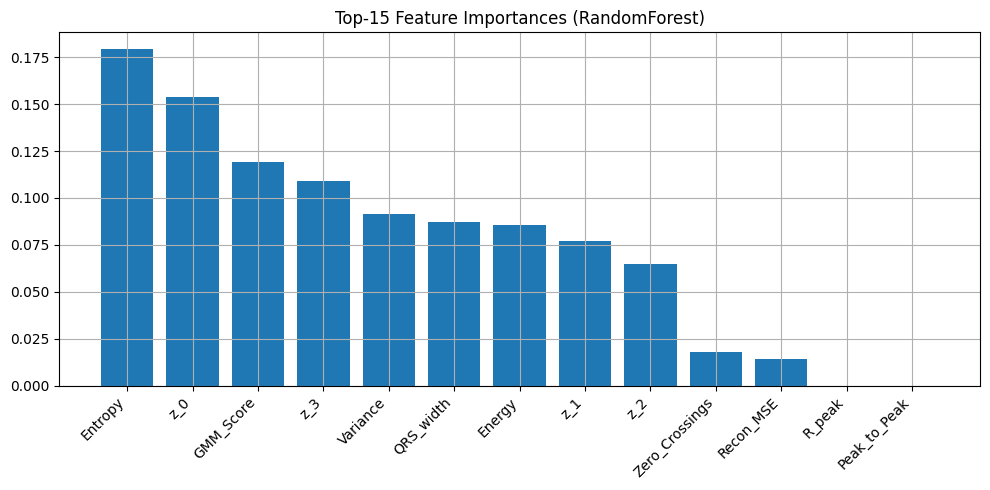

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(df_imp["Feature"][:15], df_imp["Importance"][:15])
plt.xticks(rotation=45, ha="right")
plt.title("Top-15 Feature Importances (RandomForest)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [69]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
# boyutları netleştirelim
latent_dim = z_test.shape[1]   # örn: 8
morph_dim  = morph.shape[1]    # 7

# indexler
idx_latent = slice(0, latent_dim)
idx_mse    = slice(latent_dim, latent_dim+1)
idx_gmm    = slice(latent_dim+1, latent_dim+2)
idx_morph  = slice(latent_dim+2, latent_dim+2+morph_dim)

In [70]:
ablation_sets = {
    "Latent only": X_hc[:, idx_latent],
    "Morphology only": X_hc[:, idx_morph],
    "Latent + MSE + GMM": X_hc[:, :latent_dim+2],
    "All features": X_hc
}

In [71]:
def train_eval(X, y, seed=42):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.25, random_state=seed
    )

    clf = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        class_weight="balanced",
        random_state=seed,
        n_jobs=-1
    )

    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    f1  = f1_score(y_te, y_pred, average="macro")

    return acc, f1

In [72]:
results = []

for name, X_feat in ablation_sets.items():
    acc, f1 = train_eval(X_feat, y_hc)
    results.append([name, acc, f1])

In [73]:
df_ablation = pd.DataFrame(
    results,
    columns=["Feature Set", "Accuracy", "Macro F1"]
).sort_values("Macro F1", ascending=False)

df_ablation

,Feature Set,Accuracy,Macro F1
3,All features,0.982011,0.982911
2,Latent + MSE + GMM,0.967196,0.968212
0,Latent only,0.966138,0.963322
1,Morphology only,0.971429,0.961517


In [74]:
from sklearn.metrics import roc_auc_score
import numpy as np

# 1. Skorları Birleştirme (X ekseni verisi gibi düşünebilirsiniz)
# val_ensemble_score: Normal verilerin skorları
# anom_ensemble_score: Anomali verilerin skorları
y_scores = np.concatenate([val_ensemble_score, anom_ensemble_score])

# 2. Gerçek Etiketleri Oluşturma (Y ekseni verisi)
# Normal veriler için 0, Anomali veriler için 1 atıyoruz.
# label_binarize kullanmanıza gerek yok, manuel olarak 0 ve 1 dizisi oluşturuyoruz.
y_true_binary = np.concatenate([
    np.zeros(len(val_ensemble_score)), # Normaller -> 0
    np.ones(len(anom_ensemble_score))  # Anomaliler -> 1
])

# 3. ROC AUC Hesaplama

auc_score = roc_auc_score(y_true_binary, y_scores)

print(f"Genel ROC AUC Skoru: {auc_score:.4f}")

Genel ROC AUC Skoru: 0.8462
